# Feature Engineering Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


## 1 · Load Cleaned Data

In [2]:
# Load cleaned datasets
customers   = pd.read_csv("../data/processed/customers_clean.csv")
orders      = pd.read_csv("../data/processed/orders_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
products    = pd.read_csv("../data/processed/products_clean.csv")
reviews     = pd.read_csv("../data/processed/reviews_clean.csv")

# Convert date columns
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")
orders["order_time"]     = pd.to_datetime(orders["order_time"],     errors="coerce")
reviews["review_time"]   = pd.to_datetime(reviews["review_time"],   errors="coerce")

print("Data loaded successfully")


Data loaded successfully


## 2 · Customer Features (RFM)

In [3]:
# Reference date = latest order + 1 day
reference_date = orders["order_time"].max() + pd.Timedelta(days=1)

# Recency, Frequency, Monetary in one groupby
rfm = orders.groupby("customer_id").agg({
    "order_time": lambda x: (reference_date - x.max()).days,
    "order_id":   "count",
    "total_usd":  "sum"
}).reset_index()
rfm.columns = ["customer_id", "recency", "frequency", "monetary"]
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

# Merge into full customer table (left join keeps all 20k customers)
customer_features = pd.merge(customers, rfm, on="customer_id", how="left").fillna(0)

customer_features.to_csv("../data/processed/customer_features.csv", index=False)
print("Customer features created:", customer_features.shape)


Customer features created: (20000, 11)


### Plots — RFM Distributions & Relationships

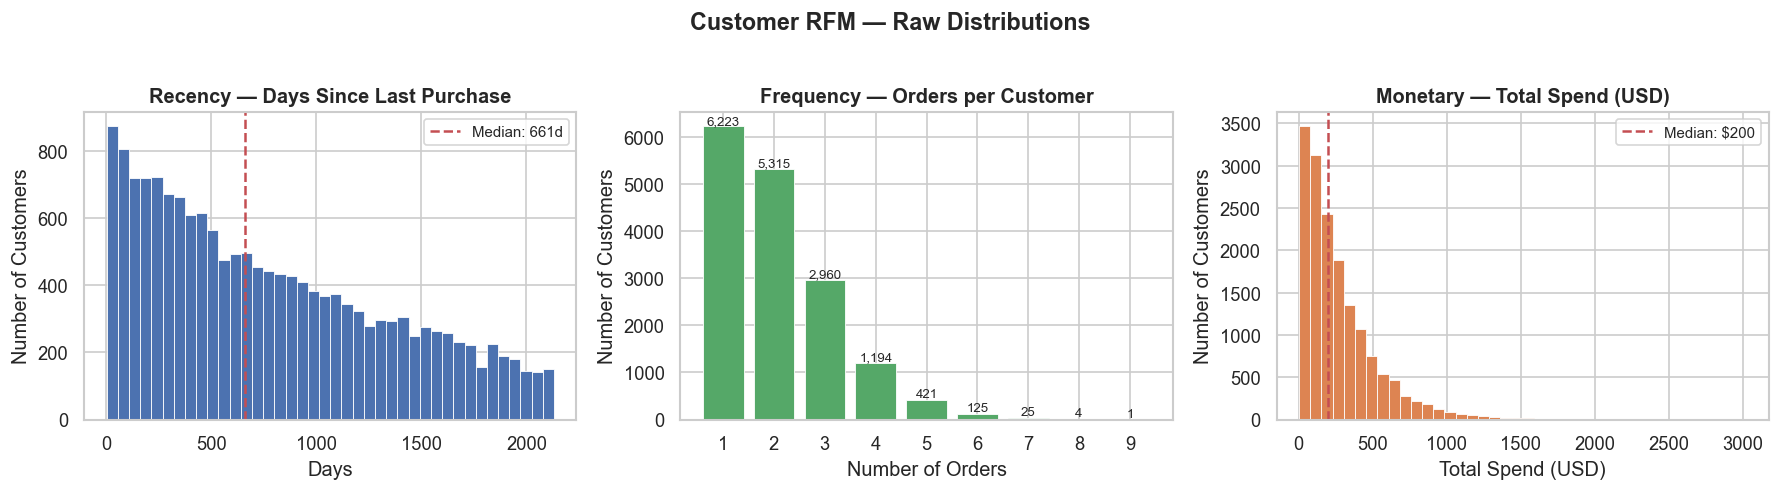

In [10]:
# ── Plot 1: RFM raw distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["recency"], bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_title("Recency — Days Since Last Purchase", fontweight="bold")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of Customers")
axes[0].axvline(rfm["recency"].median(), color="#C44E52", linestyle="--",
                linewidth=1.5, label=f'Median: {rfm["recency"].median():.0f}d')
axes[0].legend(fontsize=9)

freq_counts = rfm["frequency"].value_counts().sort_index()
axes[1].bar(freq_counts.index.astype(str), freq_counts.values,
            color="#55A868", edgecolor="white", linewidth=0.5)
axes[1].set_title("Frequency — Orders per Customer", fontweight="bold")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Customers")
for i, v in enumerate(freq_counts.values):
    axes[1].text(i, v + 60, f"{v:,}", ha="center", fontsize=8)

axes[2].hist(rfm["monetary"], bins=40, color="#DD8452", edgecolor="white", linewidth=0.5)
axes[2].set_title("Monetary — Total Spend (USD)", fontweight="bold")
axes[2].set_xlabel("Total Spend (USD)")
axes[2].set_ylabel("Number of Customers")
axes[2].axvline(rfm["monetary"].median(), color="#C44E52", linestyle="--",
                linewidth=1.5, label=f'Median: ${rfm["monetary"].median():.0f}')
axes[2].legend(fontsize=9)

fig.suptitle("Customer RFM — Raw Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/plot_rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()




## 3 · Product Features

In [5]:
# Popularity score = total units sold per product
product_popularity = order_items.groupby("product_id").agg({"quantity": "sum"}).reset_index()
product_popularity.columns = ["product_id", "popularity_score"]

# Average rating from reviews
product_ratings = reviews.groupby("product_id").agg({"rating": "mean"}).reset_index()
product_ratings.columns = ["product_id", "avg_rating"]

# Merge into product table
product_features = products.merge(product_popularity, on="product_id", how="left")
product_features = product_features.merge(product_ratings, on="product_id", how="left").fillna(0)

# Price band (low / medium / high)
product_features["price_band"] = pd.qcut(
    product_features["price_usd"], q=3,
    labels=["low", "medium", "high"], duplicates="drop"
)

product_features.to_csv("../data/processed/product_features.csv", index=False)
print("Product features created:", product_features.shape)


Product features created: (1197, 9)


### Plots — Product Feature Summary & Relationships

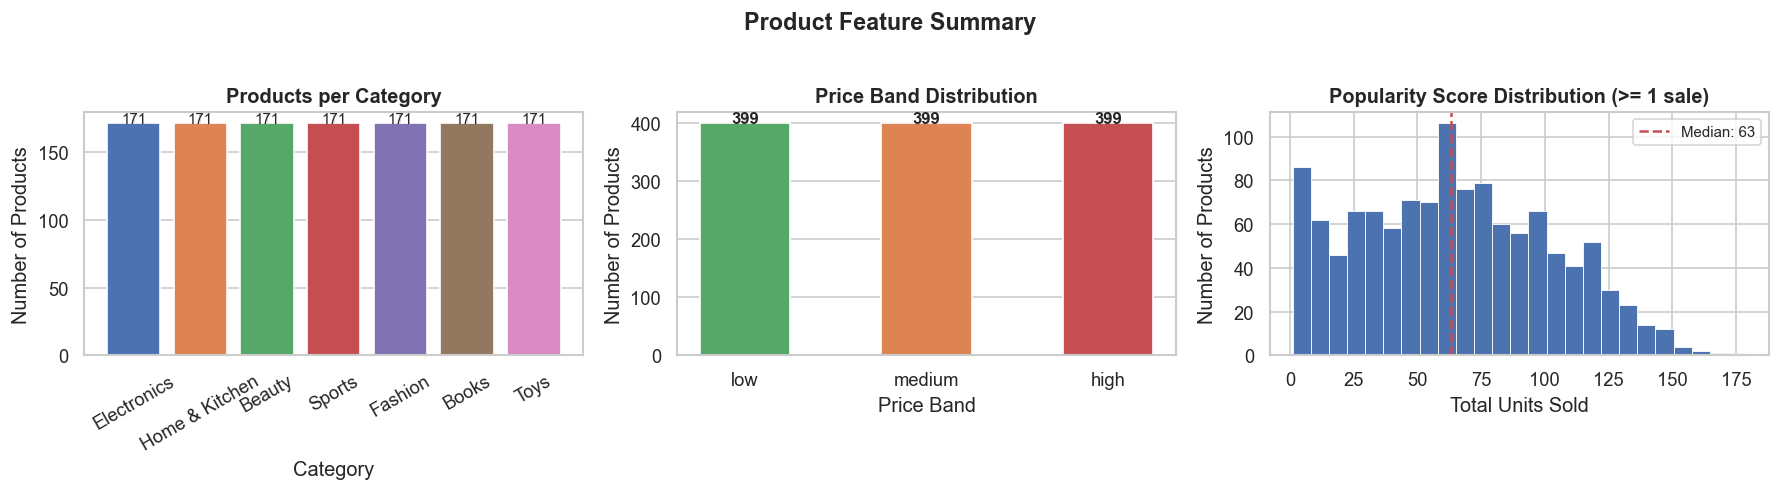

In [11]:
COLORS7 = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3"]

# ── Plot 3: Product feature overview ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cat_c = product_features["category"].value_counts().sort_values(ascending=False)
axes[0].bar(cat_c.index, cat_c.values, color=COLORS7, edgecolor="white")
axes[0].set_title("Products per Category", fontweight="bold")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of Products")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(cat_c.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=9)

band_c = product_features["price_band"].value_counts().sort_index()
axes[1].bar(band_c.index.astype(str), band_c.values,
            color=["#55A868","#DD8452","#C44E52"], edgecolor="white", width=0.5)
axes[1].set_title("Price Band Distribution", fontweight="bold")
axes[1].set_xlabel("Price Band")
axes[1].set_ylabel("Number of Products")
for i, v in enumerate(band_c.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=10, fontweight="bold")

axes[2].hist(product_features.loc[product_features["popularity_score"] > 0, "popularity_score"],
             bins=25, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[2].set_title("Popularity Score Distribution (>= 1 sale)", fontweight="bold")
axes[2].set_xlabel("Total Units Sold")
axes[2].set_ylabel("Number of Products")
axes[2].axvline(product_features["popularity_score"].median(), color="#C44E52",
                linestyle="--", linewidth=1.5,
                label=f'Median: {product_features["popularity_score"].median():.0f}')
axes[2].legend(fontsize=9)

fig.suptitle("Product Feature Summary", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/plot_product_features.png", dpi=150, bbox_inches="tight")
plt.show()




## 4 · Interaction Matrix (User × Product)

In [7]:
# Join orders → order_items to get customer–product pairs
order_product = pd.merge(
    orders[["order_id", "customer_id"]],
    order_items[["order_id", "product_id", "quantity"]],
    on="order_id", how="inner"
)

# Total units purchased per (customer, product) pair = implicit rating
interaction_matrix = order_product.groupby(["customer_id", "product_id"]).agg({
    "quantity": "sum"
}).reset_index()
interaction_matrix.columns = ["customer_id", "product_id", "purchase_count"]

interaction_matrix.to_csv("../data/processed/interaction_matrix.csv", index=False)
print("Interaction matrix created:", interaction_matrix.shape)


Interaction matrix created: (58969, 3)


### Plots — Top Products & Interaction Heatmap

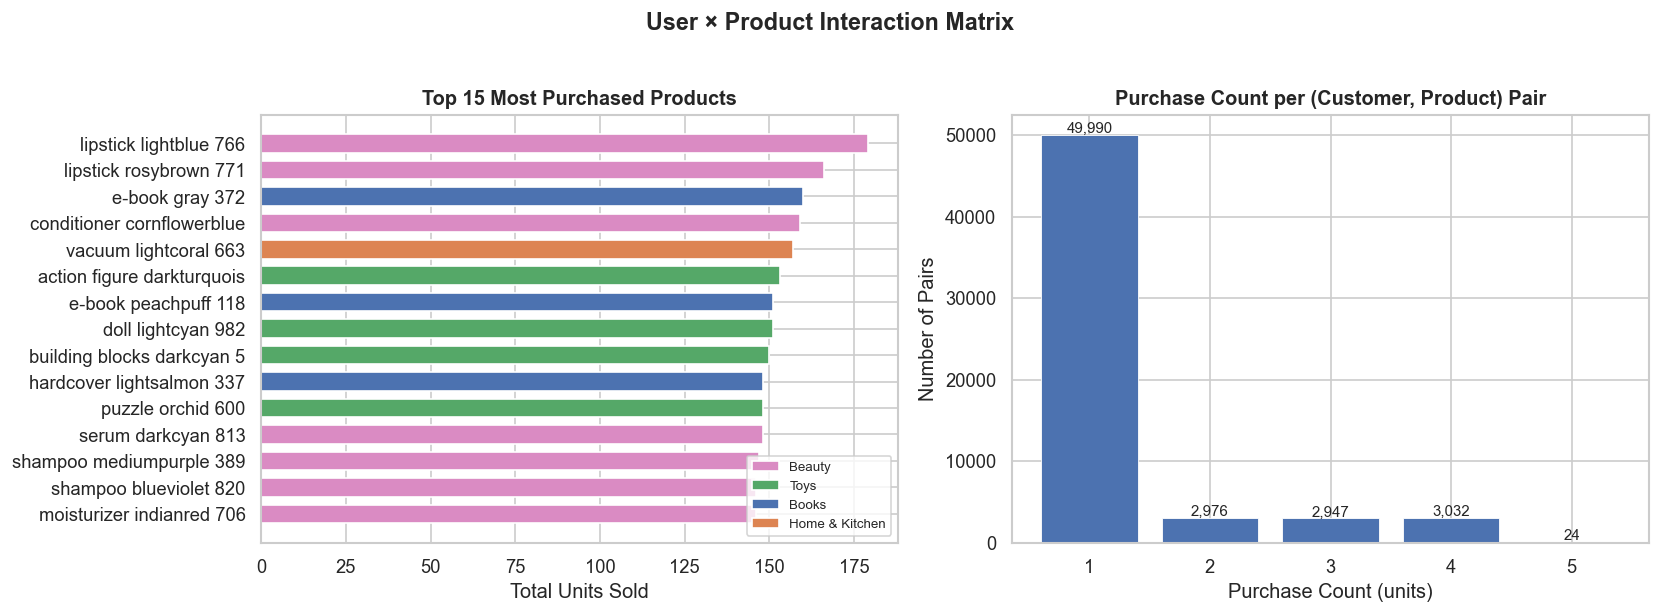

In [12]:
# ── Plot 5: Top products & purchase count distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_cat = {"Beauty":"#DA8BC3","Books":"#4C72B0","Toys":"#55A868",
              "Electronics":"#8172B3","Home & Kitchen":"#DD8452",
              "Sports":"#C44E52","Fashion":"#937860"}

top15 = (interaction_matrix.groupby("product_id")["purchase_count"].sum()
         .sort_values(ascending=False).head(15).reset_index()
         .merge(products[["product_id","name","category"]], on="product_id", how="left")
         .sort_values("purchase_count"))

bars = axes[0].barh(top15["name"].str.slice(0, 26), top15["purchase_count"],
                    color=[colors_cat.get(c,"#888") for c in top15["category"]],
                    edgecolor="white", height=0.7)
axes[0].set_title("Top 15 Most Purchased Products", fontweight="bold")
axes[0].set_xlabel("Total Units Sold")
seen = {}
for bar, cat in zip(bars, top15["category"]):
    seen.setdefault(cat, bar)
axes[0].legend(handles=[Patch(facecolor=colors_cat.get(c,"#888"), label=c) for c in seen],
               fontsize=8, loc="lower right")

pc_counts = interaction_matrix["purchase_count"].value_counts().sort_index()
axes[1].bar(pc_counts.index.astype(str), pc_counts.values,
            color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[1].set_title("Purchase Count per (Customer, Product) Pair", fontweight="bold")
axes[1].set_xlabel("Purchase Count (units)")
axes[1].set_ylabel("Number of Pairs")
for i, v in enumerate(pc_counts.values):
    axes[1].text(i, v + 300, f"{v:,}", ha="center", fontsize=9)

fig.suptitle("User × Product Interaction Matrix", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/plot_interaction_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 6: Interaction heatmap (top 20 × top 20) ─────────────────────────
top20_users    = interaction_matrix.groupby("customer_id")["purchase_count"].sum().nlargest(20).index
top20_products = interaction_matrix.groupby("product_id")["purchase_count"].sum().nlargest(20).index

heatmap_data = (
    interaction_matrix[
        interaction_matrix["customer_id"].isin(top20_users) &
        interaction_matrix["product_id"].isin(top20_products)
    ]
    .pivot(index="customer_id", columns="product_id", values="purchase_count")
    .fillna(0)
)



## Summary

In [9]:
print("Feature Engineering Completed Successfully!")
print("Customer Features Shape :", customer_features.shape)
print("Product Features Shape  :", product_features.shape)
print("Interaction Matrix Shape:", interaction_matrix.shape)


Feature Engineering Completed Successfully!
Customer Features Shape : (20000, 11)
Product Features Shape  : (1197, 9)
Interaction Matrix Shape: (58969, 3)
